<span style="color:teal; font-size:40px">📋**EDA**👨🏾‍💻

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

<span style="color:olive; font-size:20px">**Carreguem les dades actualitzades**</span>

In [3]:
df_RRHH = pd.read_csv('raw_data_01062026.csv')

In [4]:
df_RRHH

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
1,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
2,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
3,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112
4,9,12,3,3,2,228,14,16,58,"222,196",...,0,1,2,0,0,1,65,172,22,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
841,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
842,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
843,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112


In [5]:
df_RRHH.shape

(845, 21)

In [6]:
df_RRHH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       845 non-null    int64 
 1   Reason_absence           845 non-null    int64 
 2   Month_absence            845 non-null    int64 
 3   Day_week                 845 non-null    int64 
 4   Seasons                  845 non-null    int64 
 5   Transportation_expense   845 non-null    int64 
 6   Distance_Residence_Work  845 non-null    int64 
 7   Service_time             845 non-null    int64 
 8   Age                      845 non-null    int64 
 9   Work_load_Average_day    845 non-null    object
 10  Hit_target               845 non-null    int64 
 11  Disciplinary_failure     845 non-null    int64 
 12  Education                845 non-null    int64 
 13  Son                      845 non-null    int64 
 14  Social_drinker           845 non-null    i

<span style="color:teal; font-size:16px">**Valores unicos por columna**</span>

In [7]:
valores_unicos= {col: df_RRHH[col].nunique() for col in df_RRHH.columns}
valores_unicos

{'ID': 136,
 'Reason_absence': 28,
 'Month_absence': 13,
 'Day_week': 5,
 'Seasons': 4,
 'Transportation_expense': 24,
 'Distance_Residence_Work': 25,
 'Service_time': 18,
 'Age': 22,
 'Work_load_Average_day': 38,
 'Hit_target': 13,
 'Disciplinary_failure': 2,
 'Education': 4,
 'Son': 5,
 'Social_drinker': 2,
 'Social_smoker': 2,
 'Pet': 6,
 'Weight': 26,
 'Height': 14,
 'Body_mass_index': 17,
 'Absenteeism_hours': 19}

In [13]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Month_absence', 'Day_week', 'Seasons',
       'Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure',
       'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight',
       'Height', 'Body_mass_index', 'Absenteeism_hours'],
      dtype='object')

<span style="font-size:14px">Distribución de columnas: </span>

In [14]:
# Categóricas
cat_cols = ['Reason_absence', 'Month_absence', 'Day_week', 'Seasons',
            'Disciplinary_failure', 'Education', 'Son',
            'Social_drinker', 'Social_smoker', 'Pet']

# Numéricas continuas
num_cols = ['Transportation_expense', 'Distance_Residence_Work', 'Service_time',
            'Age', 'Work_load_Average_day', 'Hit_target',
            'Weight', 'Height', 'Body_mass_index', 'Absenteeism_hours']

<span style=color:olive; font-size:16px>**Control de registros**</span>

In [7]:
def control_registros(df, col_id="ID"):
    total_registros = len(df)
    ids_unicos = df[col_id].nunique()
    ids_extra = total_registros - ids_unicos
    duplicados_exactos = df.duplicated().sum()

    print("═══════════════════════════════════")
    print("       CONTROL DE REGISTROS        ")
    print("═══════════════════════════════════")
    print(f"  TOTAL REGISTROS       : {total_registros}")
    print(f"  ID ÚNICOS             : {ids_unicos}")
    print(f"  ID EXTRAS             : {ids_extra}")
    print(f"  ID DUPLICADOS EXACTOS : {duplicados_exactos}")
    print("═══════════════════════════════════")

In [8]:
control_registros(df_RRHH)

═══════════════════════════════════
       CONTROL DE REGISTROS        
═══════════════════════════════════
  TOTAL REGISTROS       : 845
  ID ÚNICOS             : 136
  ID EXTRAS             : 709
  ID DUPLICADOS EXACTOS : 39
═══════════════════════════════════


<span style="color:red; font-size:14px">**Revisar** ***ID DUPLICADOS EXACTOS***</span>

<span style="color: olive; font-size:20px">**Análisis descriptivo**</span>

In [9]:
df_RRHH.describe()

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Hit_target,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
count,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000
mean,26.128994,19.280473,6.315976,3.926627,2.540828,220.482840,29.418935,12.578698,36.443787,94.572781,0.047337,1.282840,1.000000,0.560947,0.072189,0.730178,79.014201,172.110059,26.673373,7.368047
std,26.374062,8.296957,3.457020,1.417331,1.111040,67.416501,14.740235,4.424460,6.555322,3.798349,0.212485,0.663362,1.084138,0.496566,0.258954,1.278922,12.877744,5.965220,4.274061,15.168194
min,1.000000,0.000000,0.000000,2.000000,1.000000,118.000000,5.000000,1.000000,27.000000,81.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,56.000000,163.000000,19.000000,0.000000
25%,10.000000,13.000000,3.000000,3.000000,2.000000,179.000000,16.000000,9.000000,31.000000,93.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,169.000000,24.000000,2.000000
50%,20.000000,23.000000,6.000000,4.000000,3.000000,225.000000,26.000000,12.000000,37.000000,95.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,83.000000,170.000000,25.000000,3.000000
75%,33.000000,26.000000,9.000000,5.000000,4.000000,260.000000,49.000000,16.000000,40.000000,97.000000,0.000000,1.000000,2.000000,1.000000,0.000000,1.000000,89.000000,172.000000,31.000000,8.000000
max,136.000000,28.000000,12.000000,6.000000,4.000000,388.000000,52.000000,29.000000,58.000000,100.000000,1.000000,4.000000,4.000000,1.000000,1.000000,8.000000,108.000000,196.000000,38.000000,120.000000


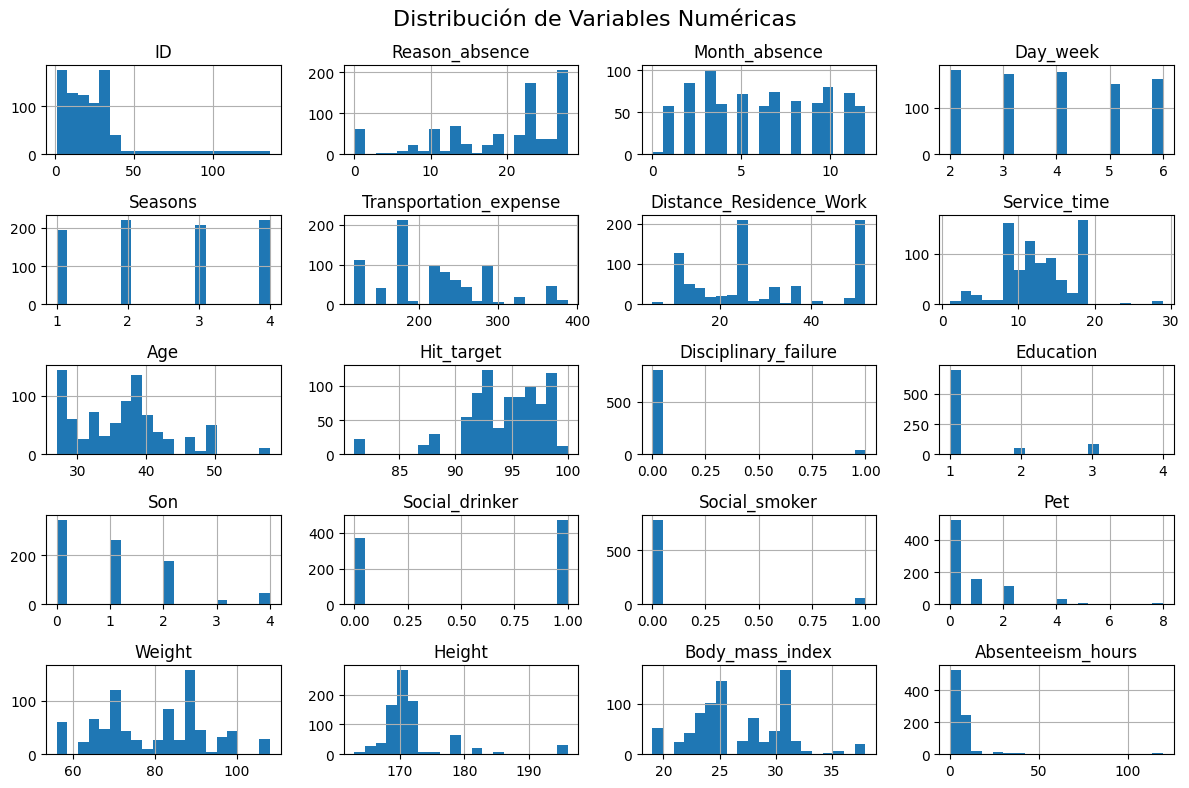

In [10]:
df_RRHH.hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribución de Variables Numéricas", fontsize=16)
plt.tight_layout()
plt.show()

<span style="color: pink; font-size:14px">**Excluimos las columnas** ***Disciplinary_failure, Social_drinker, Social_smoker, Education*** **de los histogramas por ser categóricas**</span>

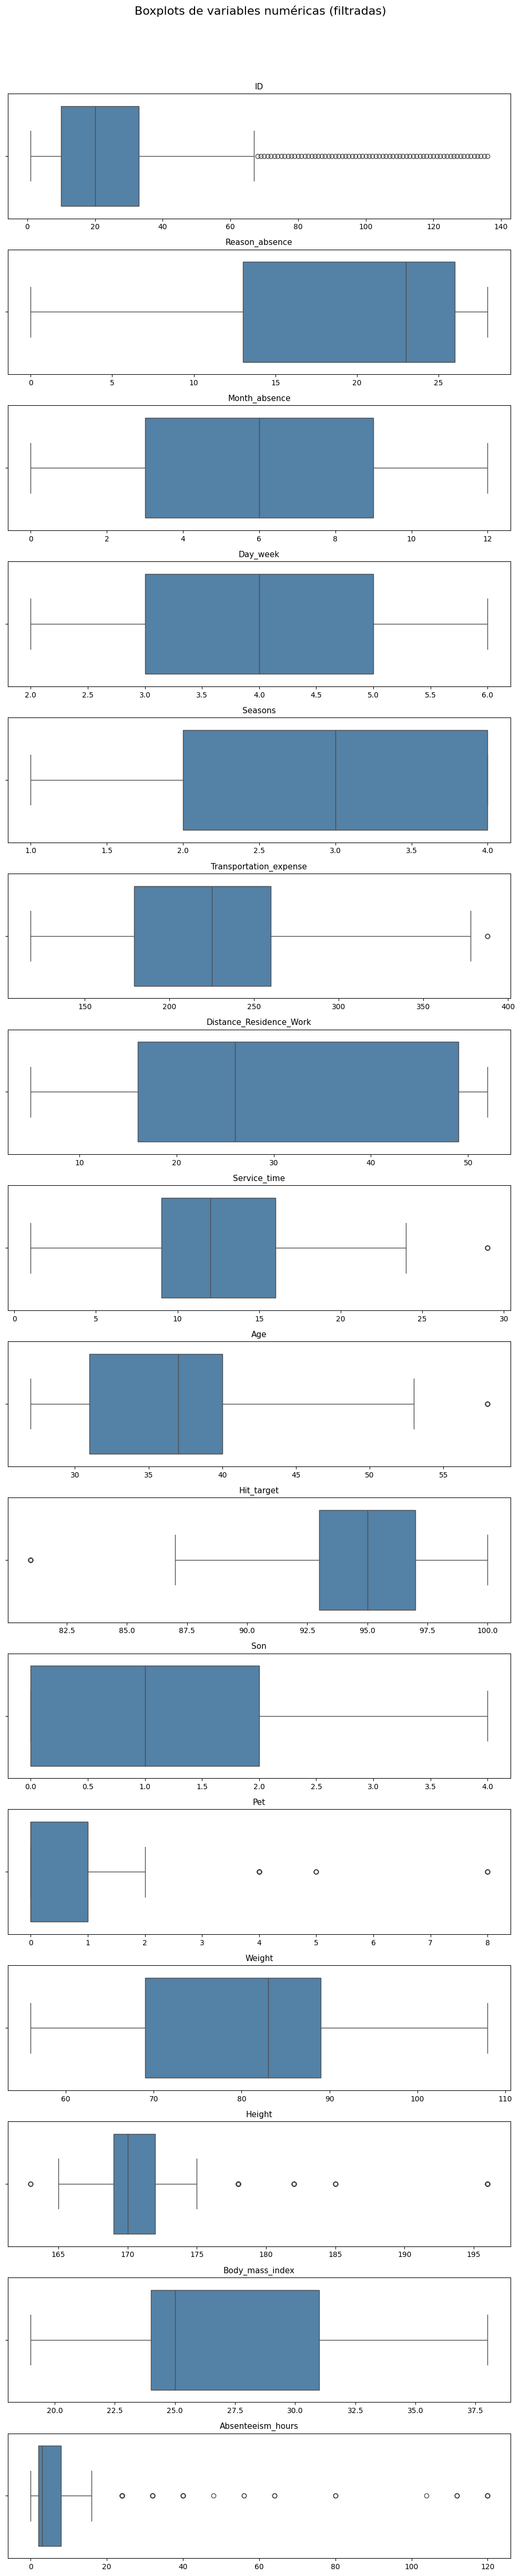

In [11]:
cols_excluir = ['Disciplinary_failure', 'Social_drinker', 'Social_smoker', 'Education']
num_cols = df_RRHH.select_dtypes(include=[np.number]).columns.tolist()
num_cols_filtradas = [col for col in num_cols if col not in cols_excluir]
fig, axes = plt.subplots(len(num_cols_filtradas), 1, figsize=(10, 3 * len(num_cols_filtradas)))
if len(num_cols_filtradas) == 1:
    axes = [axes]
for ax, col in zip(axes, num_cols_filtradas):
    sns.boxplot(x=df_RRHH[col], ax=ax, color="steelblue")
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.suptitle("Boxplots de variables numéricas (filtradas)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

<span style="color: rgba(245, 169, 240, 0.97); font-size:14px">**Observamos que la distribución de los datos en las diferentes columnas/variables es bastante heterogenea y asimétrica en algunas de ellas, con outliers muy marcados en ***Absenteeism_hours***, ***Height*** y ***Pet***.**</span>

In [12]:
df_RRHH.groupby('ID')[['Absenteeism_hours']].sum().sort_values(by='Absenteeism_hours', ascending=True).head(10)

,Absenteeism_hours
ID,
4,0
8,0
35,0
38,1
50,1
44,1
58,1
125,1
101,1


In [14]:
#Cuantos ids diferentes hay en el df_RRHH?
df_RRHH['ID'].nunique()

136

In [11]:
#lista de todos los ids del df_RRHH
lista_ids=df_RRHH['ID'].unique().tolist()
print(lista_ids)

[14, 36, 9, 28, 11, 13, 34, 22, 26, 20, 10, 15, 17, 24, 3, 18, 7, 1, 30, 5, 6, 2, 31, 27, 33, 23, 21, 25, 12, 32, 16, 29, 19, 8, 4, 35, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136]


In [16]:
df_RRHH

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
1,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
2,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
3,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112
4,9,12,3,3,2,228,14,16,58,"222,196",...,0,1,2,0,0,1,65,172,22,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
841,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
842,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
843,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112


<span style="color: rgba(235, 150, 213, 0.87); font-size:16px">**¿El work load y el hit target varian semanalmente o mensualmente?**</span>

In [17]:
#Siempre que hay el work_load, hay el mismo hit_target?
df_RRHH.groupby('Month_absence')[['Day_week','Hit_target', 'Work_load_Average_day']]

In [18]:
for nombre, grupo in df_RRHH.groupby('Month_absence'):
    print(f"Mes: {nombre}")
    print(grupo[['ID','Day_week', 'Hit_target', 'Work_load_Average_day']])
    print("-" * 50)

Mes: 0
     ID  Day_week  Hit_target Work_load_Average_day
737   4         3          95               271,219
738   8         4          95               271,219
739  35         6          95               271,219
--------------------------------------------------
Mes: 1
      ID  Day_week  Hit_target Work_load_Average_day
26    34         2         100               330,061
40    22         2          96               313,532
61    22         5          96               313,532
94    14         3          95               308,593
95    22         3          95               308,593
96    11         3          95               308,593
171   11         2         100               330,061
172   15         4         100               330,061
173    5         2         100               330,061
229   32         5          96               313,532
230   14         3          96               313,532
231   11         4          96               313,532
276   28         4         100        

<span style="color: green; font-size:20px">**Observaciones**</span>:

- <span style="font-size:14px"> **ID**: Hay 3 registros con ID en Mes 0. Son los mismos que tienen tienen reason of absence igual a 0.

- <span style="font-size:14px"> **El Hit target y el work load**: Estas columnas estan relacionadas, entedemos como ***hit target*** el objetivo de entregas o tareas, y ***work load*** la carga de trabajo. La relación entre estas dos variables puede indicar que a medida que aumenta el objetivo de entregas, también aumenta la carga de trabajo, lo que es lógico en un entorno laboral. Podemos observar también que estos van variando en función del mes y no tanto por día de la semana, lo que sugiere que la planificación mensual puede ser un factor importante en la gestión de la carga de trabajo.



In [19]:
#cuantos registros hay con Reason_absence igual a 0?
df_RRHH[df_RRHH['Reason_absence'] == 0].shape[0]

43

In [20]:
#cuantos registros hay con Month_absence igual a 0 y cuales son?
df_RRHH[df_RRHH['Month_absence'] == 0]

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
737,4,0,0,3,1,118,14,13,40,"271,219",...,0,1,1,1,0,8,98,170,34,0
738,8,0,0,4,2,231,35,14,39,"271,219",...,0,1,2,1,0,2,100,170,35,0
739,35,0,0,6,3,179,45,14,53,"271,219",...,0,1,1,0,0,1,77,175,25,0


In [21]:
df_RRHH[df_RRHH['Reason_absence'] == 0]

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
696,36,0,7,3,1,118,13,18,50,"239,554",...,1,1,1,1,0,0,98,178,31,0
697,20,0,9,2,4,260,50,11,36,"241,476",...,1,1,4,1,0,0,65,168,23,0
698,29,0,9,2,4,225,26,9,28,"241,476",...,1,1,1,0,0,2,69,169,24,0
699,11,0,9,3,4,289,36,13,33,"241,476",...,1,1,2,1,0,1,90,172,30,0
700,36,0,9,3,4,118,13,18,50,"241,476",...,1,1,1,1,0,0,98,178,31,0
701,13,0,9,4,4,369,17,12,31,"241,476",...,1,1,3,1,0,0,70,169,25,0
702,36,0,10,4,4,118,13,18,50,"253,465",...,1,1,1,1,0,0,98,178,31,0
704,2,0,4,2,3,235,29,12,48,"326,452",...,1,1,1,0,1,5,88,163,33,0
705,7,0,5,4,3,279,5,14,39,"378,884",...,1,1,2,1,1,0,68,168,24,0
706,18,0,5,4,3,330,16,4,28,"378,884",...,1,2,0,0,0,0,84,182,25,0


<span style="color: rgba(234, 160, 229, 0.95); font-size:16px">**¿Todos los empleados con registro de ausencia igual a 0 tienen falta disciplinaria (Disciplinary_failure)?**</span>

In [22]:
Reason_absence_0 = df_RRHH[df_RRHH['Reason_absence'] == 0][['ID', 'Reason_absence', 'Disciplinary_failure', 'Absenteeism_hours']]
Reason_absence_0

,ID,Reason_absence,Disciplinary_failure,Absenteeism_hours
696,36,0,1,0
697,20,0,1,0
698,29,0,1,0
699,11,0,1,0
700,36,0,1,0
701,13,0,1,0
702,36,0,1,0
704,2,0,1,0
705,7,0,1,0
706,18,0,1,0


<span style="font-size:14px">Observamos que no todos los empleados, menos 3, con registro de ausencia igual a 0 tienen falta disciplinaria.</span> 

<span style="font-size:14px">**Podemos plantear las siguientes preguntas a razón de esta observación**:</span>

   - <span style="font-size:14px">¿Qué características tienen en común los empleados que no tienen ausencia pero sí falta disciplinaria? 
   - <span style="font-size:14px">¿Podría haber factores subyacentes que expliquen esta situación, como problemas de comportamiento o desempeño laboral?</span>

<span style="color: orange; font-size:20px">**Exploración por Season**</span>

In [23]:
df_RRHH[['Month_absence', 'Seasons']]

,Month_absence,Seasons
0,11,4
1,4,3
2,7,1
3,7,1
4,3,2
...,...,...
840,11,4
841,4,3
842,7,1
843,7,1


In [24]:
#quiero una lista de los meses por estacion
estaciones = df_RRHH.groupby('Seasons')['Month_absence'].unique()
print(estaciones)

Seasons
1     [7, 8, 9, 6, 0]
2    [3, 12, 1, 2, 0]
3     [4, 3, 6, 5, 0]
4     [11, 12, 10, 9]
Name: Month_absence, dtype: object


<span >